In [85]:
import numpy as np
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.hrf import Optimise_HRF
from imaging_pipelines.hrf import calc_R2
import seaborn as sb
import matplotlib.pyplot as plt
import os
import pandas as pd

In [86]:
experiment = 'smp2'
sn = 113
glm = 12
gridsearch = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', 'hrf_gridsearch.tsv'), sep='\t')
gridsearch = gridsearch[gridsearch.sn==sn]
gridsearch_max = gridsearch.loc[gridsearch.groupby('roi')['R_squared'].idxmax()]
display(gridsearch_max[['delay_response', 'delay_undershoot', 'ratio', 'R_squared', 'roi']])

,delay_response,delay_undershoot,ratio,R_squared,roi
17465,9.0,10.0,7.0,0.117626,M1
17033,9.0,10.0,7.0,0.134254,PMd
17249,9.0,10.0,7.0,0.127507,PMv
17681,9.0,10.0,7.0,0.166218,S1
16817,9.0,10.0,7.0,0.105284,SMA
17897,9.0,10.0,7.0,0.161571,SPLa
18113,9.0,10.0,7.0,0.145038,SPLp


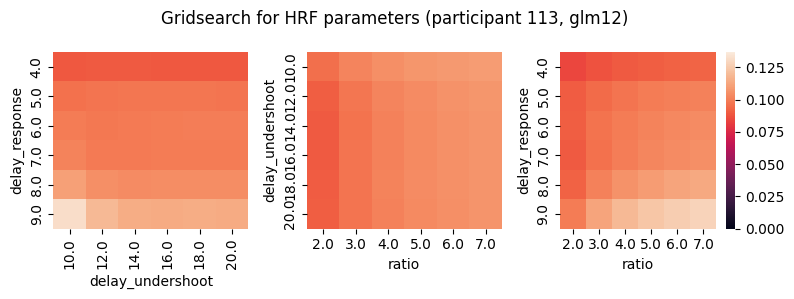

In [87]:
# find best parameters
gridsearch_avg = gridsearch.groupby(gl.hrf_params)['R_squared'].mean().reset_index() # [gridsearch.roi.isin(['M1', 'S1'])]
idxmax = gridsearch_avg.R_squared.argmax()

# plot gridsearch
fig, axs = plt.subplots(1, 3, figsize=(8, 3))
pairs = [('delay_response', 'delay_undershoot'), ('delay_undershoot', 'ratio'), ('delay_response', 'ratio')]
vmin, vmax = 0, gridsearch_avg.R_squared.max()
for p, pair in enumerate(pairs):
    ax = axs[p]
    data = gridsearch_avg.pivot_table(index=pair[0], columns=pair[1], values='R_squared', aggfunc='mean')
    sb.heatmap(data=data, ax=ax, vmin=vmin, vmax=vmax, cbar=True if p==2 else False)
fig.suptitle(f'Gridsearch for HRF parameters (participant {sn}, glm{glm})')
fig.tight_layout()

plt.show()

In [88]:
gridsearch_avg

,delay_response,delay_undershoot,dispersion_response,dispersion_undershoot,ratio,onset,length,R_squared
0,4.0,10.0,1.0,1.0,2.0,0.0,32.0,0.084030
1,4.0,10.0,1.0,1.0,3.0,0.0,32.0,0.087063
2,4.0,10.0,1.0,1.0,4.0,0.0,32.0,0.088983
3,4.0,10.0,1.0,1.0,5.0,0.0,32.0,0.090260
4,4.0,10.0,1.0,1.0,6.0,0.0,32.0,0.091160
...,...,...,...,...,...,...,...,...
211,9.0,20.0,1.0,1.0,3.0,0.0,32.0,0.107366
212,9.0,20.0,1.0,1.0,4.0,0.0,32.0,0.114847
213,9.0,20.0,1.0,1.0,5.0,0.0,32.0,0.119647
214,9.0,20.0,1.0,1.0,6.0,0.0,32.0,0.122960


P=[6,12,1,1,6,0,32.0], R2=0.1105273962773704


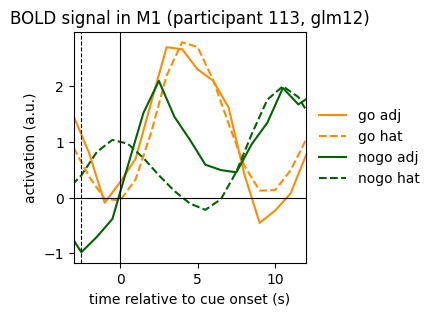

In [91]:
roi = 'M1'
HRF = Optimise_HRF(sn=sn, glm=glm)
P = [6, 12, 1, 1, 6, 0, 32.0]
#P = gridsearch_avg.loc[idxmax][gl.hrf_params].to_numpy()
y_hat, y_adj, y_cut_hat_go, y_cut_adj_go, y_cut_hat_nogo, y_cut_adj_nogo = HRF.manual(P, roi=roi, pre=3, post=16)
R2 = calc_R2(y_adj, y_hat)
print(f'P=[{",".join(map(str, P))}], R2={R2}')

fig, ax = plt.subplots(figsize=(3, 3),)

tAx_go = np.arange(-3, 17)
tAx_nogo = tAx_go - 2.5

ax.plot(tAx_go, y_cut_adj_go.mean(axis=(0, -1)), color='darkorange', label='go adj')
ax.plot(tAx_go, y_cut_hat_go.mean(axis=(0, -1)), color='darkorange', ls='--', label='go hat')
ax.plot(tAx_nogo, y_cut_adj_nogo.mean(axis=(0, -1)), color='darkgreen', label='nogo adj')
ax.plot(tAx_nogo, y_cut_hat_nogo.mean(axis=(0, -1)), color='darkgreen', ls='--', label='nogo hat')

ax.axvline(0, color='k', ls='-', lw=.8)
ax.axvline(-2.5, color='k', ls='--', lw=.8)
ax.axhline(0, color='k', ls='-', lw=.8)

ax.set_xlim((-3, 12))
ax.set_xlabel(None)
ax.set_ylabel('activation (a.u.)')
ax.set_xlabel('time relative to cue onset (s)')
ax.set_title(f'BOLD signal in {roi} (participant {sn}, glm{glm})')
ax.legend(frameon=False, bbox_to_anchor=(1, .5), loc='center left')

plt.show()